In [1]:
import pandas as pd

df = pd.read_csv("Sale.csv")

print(df.shape)
df.info()

(113036, 23)
<class 'pandas.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              113036 non-null  str    
 1   Day               113036 non-null  int64  
 2   Month             113036 non-null  str    
 3   Year              113036 non-null  int64  
 4   Customer_Age      113036 non-null  int64  
 5   Age_Group         113036 non-null  str    
 6   Customer_Gender   113036 non-null  str    
 7   Country           113036 non-null  str    
 8   State             113036 non-null  str    
 9   Product_Category  113036 non-null  str    
 10  Sub_Category      113036 non-null  str    
 11  Product           113036 non-null  str    
 12  Order_Quantity    113036 non-null  int64  
 13  Unit_Cost         113036 non-null  int64  
 14  Unit_Price        113036 non-null  int64  
 15  Profit            113036 non-null  int64  
 16  Cost              

In [2]:
df["Date"] = pd.to_datetime(df["Date"])
print(df["Date"].min(), df["Date"].max())

2011-01-01 00:00:00 2016-07-31 00:00:00


In [3]:
print(df.describe())                      
print(df.describe(include="object"))      

                             Date            Day           Year  \
count                      113036  113036.000000  113036.000000   
mean   2014-11-23 12:14:55.063519      15.665753    2014.401739   
min           2011-01-01 00:00:00       1.000000    2011.000000   
25%           2013-12-22 00:00:00       8.000000    2013.000000   
50%           2014-06-27 00:00:00      16.000000    2014.000000   
75%           2016-01-09 00:00:00      23.000000    2016.000000   
max           2016-07-31 00:00:00      31.000000    2016.000000   
std                           NaN       8.781567       1.272510   

        Customer_Age  Order_Quantity      Unit_Cost     Unit_Price  \
count  113036.000000   113036.000000  113036.000000  113036.000000   
mean       35.919212       11.901660     267.296366     452.938427   
min        17.000000        1.000000       1.000000       2.000000   
25%        28.000000        2.000000       2.000000       5.000000   
50%        35.000000       10.000000       9.0

C:\Users\Aditya Malguri\AppData\Local\Temp\ipykernel_17576\545796548.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


In [4]:

print(df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False))


print(df.groupby("Country")["Revenue"].sum().sort_values(ascending=False))

print(df.groupby("Year")["Revenue"].sum())

Product_Category
Bikes          61782134
Accessories    15117992
Clothing        8370882
Name: Revenue, dtype: int64
Country
United States     27975547
Australia         21302059
United Kingdom    10646196
Germany            8978596
France             8432872
Canada             7935738
Name: Revenue, dtype: int64
Year
2011     8964888
2012     9175983
2013    15240037
2014    14152724
2015    20023991
2016    17713385
Name: Revenue, dtype: int64


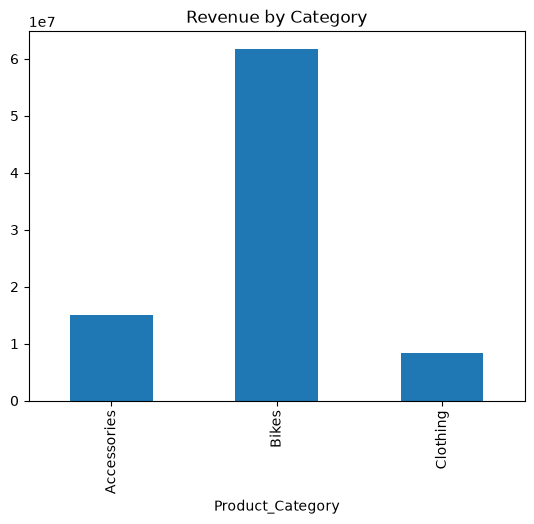

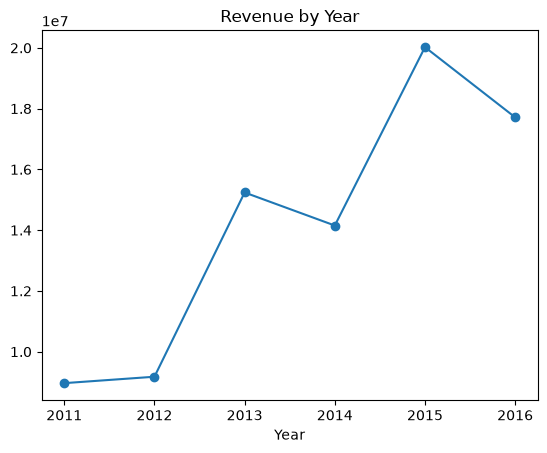

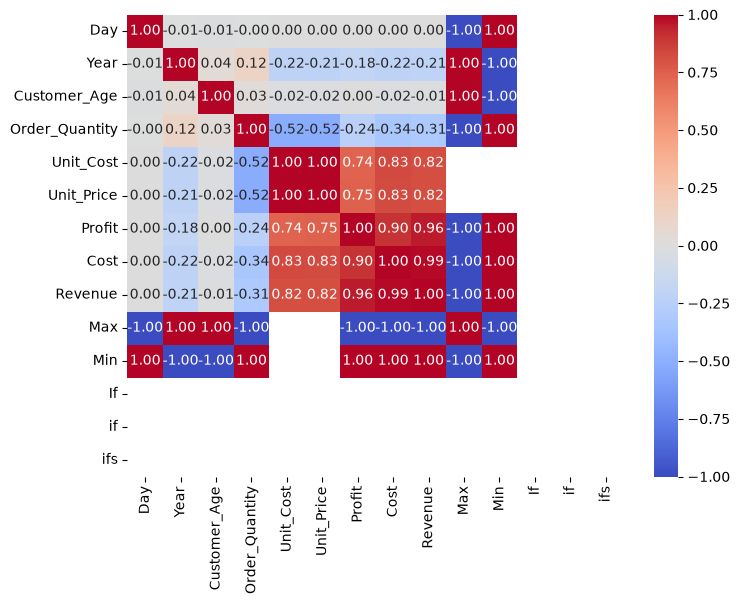

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


df.groupby("Product_Category")["Revenue"].sum().plot(kind="bar", title="Revenue by Category")
plt.show()


df.groupby("Year")["Revenue"].sum().plot(kind="line", marker="o", title="Revenue by Year")
plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ["Order_Quantity", "Unit_Cost", "Unit_Price", "Cost", "Customer_Age"]
X = df[features]
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 4.32,-2.35, 1.42, 1.47, 0.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Order_Quantity','Unit_Cost','Unit_Price','Cost','Customer_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-21.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [9]:
y_pred = model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

print("Coefficients:", dict(zip(features, model.coef_)))
print("Intercept:", model.intercept_)

R² score: 0.982053404487323
RMSE: 170.7685606745784
Coefficients: {'Order_Quantity': np.float64(4.320321096534661), 'Unit_Cost': np.float64(-2.351891823206196), 'Unit_Price': np.float64(1.4219260450808733), 'Cost': np.float64(1.4668375901782786), 'Customer_Age': np.float64(0.5906190292537588)}
Intercept: -21.73947071698774
